In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
import pyreadstat
import requests
import time
import urllib.request
import os
import gtfs_kit as gk
import zipfile
import statsmodels
import json

In [3]:
# =============================================================================
# LONDON CONFIGURATION BLOCK
# Source: NTS Data Extract User Guide + Main Table Variables London.csv
# =============================================================================

# ---- File paths ----
nts_files = {
    "trip": r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\london\raw\UKDA-5340-tab\tab\trip_eul_2002-2024.tab",
    "individual": r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\london\raw\UKDA-5340-tab\tab\individual_eul_2002-2024.tab",
    "household": r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\london\raw\UKDA-5340-tab\tab\household_eul_2002-2024.tab",
    "psu": r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\london\raw\UKDA-5340-tab\tab\psu_eul_2002-2024.tab",
    "day": r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\london\raw\UKDA-5340-tab\tab\day_eul_2002-2024.tab",
}

# ---- Year filter (applied at load time for memory efficiency) ----
survey_year = 2023

# ---- Geographic filter ----
# London code — PSUStatsReg_B01ID 
london_code = 8  

# ---- Trip purpose filter (TripPurpose_B04ID, 8 categories) ----
commute_code_london = 1

# ---- Mode codes (MainMode_B04ID, 13 categories) ----
mode_car_driver  = 3
mode_bicycle     = 2
mode_bus_london  = 7
mode_bus_other   = 8
mode_underground = 10 # Underground + DLR + light rail + tram
mode_other_pt = 13 

# Choice set: car driver, PT (bus + underground), bicycle
pt_codes_london  = [mode_bus_london, mode_bus_other, mode_underground, mode_other_pt]
choice_modes_london = [mode_car_driver] + pt_codes_london + [mode_bicycle]

# ---- Weekday filter (TravelWeekDay_B01ID) ----
weekday_codes_london = [1, 2, 3, 4, 5]   # Mon–Fri

# ---- Holiday filter (TravelDayType_B01ID, from 2008 onwards) ----
# 1 = Normal day, 2+ = bank holiday / special day
normal_day_code = 1

# ---- Socioeconomic missing codes (NTS convention) ----
# -8 = "Don't know", -9 = "Not answered/applicable"
missing_codes = [-8, -9, -10]

# ---- Driving licence (DrivLic_B02ID, 3 categories) ----
# 1 = Full licence, 2 = Provisional, 3 = No licence
full_licence_code = 1

# ---- Income variable (year-specific quintiles for England) ----
income_var_2023 = "HHIncQIS2023Eng_B01ID"  # interview-sample quintiles

# ---- Purpose labels (for EDA bar chart) ----
purpose_labels = {
    1: "Commuting", 2: "Business", 3: "Education", 4: "Escort",
    5: "Shopping", 6: "Other personal", 7: "Leisure", 8: "Other/walk"
}

# --- Distance conversion ---
miles_to_km = 1.609344    # AfstV is recorded in hectometers

# --- Cleaning thresholds --- Same as in Amsterdam dataset
min_trip_dur = 2 # in mins; below 2mins likely data entry error
max_trip_dur = 120 # in mins; 
min_trip_distance = 0.2 # in km; below is unlikely for any of our three modes
max_trip_distance = 50 # in km;

# --- Peak hour definition --- Same as in Amsterdam Dataset
am_peak_start = 6 
am_peak_end   = 9
pm_peak_start = 16
pm_peak_end   = 19

# ---- Mode labels (for EDA charts, all 13 categories) ----
mode_labels_b04 = {
     1: "Walk",  2: "Bicycle",  3: "Car driver",  4: "Car passenger",
     5: "Motorcycle",  6: "Other private",  7: "Bus (London)",
     8: "Other local bus",  9: "Non-local bus/coach",
    10: "Underground/metro/LR", 11: "Surface rail",
    12: "Taxi/minicab", 13: "Other public"
}

In [4]:
# Shared columns list
shared_columns = [
    "person_id", "trip_id", "trip_purpose", "mode_detailed",
    "travel_time_min", "distance_km", "departure_hour",
    "weekday", "is_holiday", "age_band", "gender",
    "income_quintile", "has_driving_license", "n_cars_household",
    "weight_trip", "weight_person", "city", "is_peak", "chosen_mode",
    "n_transfers", "has_transfer", "n_legs"
]

# ---- Choice set labels (dependent variable) ----
choice_set = ["car", "pt", "bike"]

# ---- Age bands (matching NTS Age_B04ID 9-category scheme) ----
#   Code 1: 0-4, 2: 5-10, 3: 11-16, 4: 17-20, 5: 21-29,
#   6: 30-39, 7: 40-49, 8: 50-59, 9: 60+
age_bins  = [0, 5, 11, 17, 21, 30, 40, 50, 60, 200]
age_labels = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# ---- Income: Amsterdam decile → quintile mapping ----
# ODiN HHGestInkG deciles 1-10 → quintiles 1-5
decile_to_quintile= {
    1: 1, 2: 1,   # Q1 (lowest)
    3: 2, 4: 2,   # Q2
    5: 3, 6: 3,   # Q3
    7: 4, 8: 4,   # Q4
    9: 5, 10: 5,  # Q5 (highest)
}

In [5]:
print("London config loaded.")
print(f"  Survey year : {survey_year}")
print(f"  PT codes    : {pt_codes_london}")
print(f"  Choice set  : car({mode_car_driver}), PT{pt_codes_london}, bike({mode_bicycle})")

London config loaded.
  Survey year : 2023
  PT codes    : [7, 8, 10, 13]
  Choice set  : car(3), PT[7, 8, 10, 13], bike(2)


## 1. Data Source Declaration

As a second datasource we are going to use the UK National Travel Survey (NTS) for 2023. This section is going to mirrors the Amsterdam pipeline: load → inspect → filter → rename → validate.

The target output is a `london_processed` dataframe with the same 19 shared-schema columns as in amsterdams data.

**Data source:** UK National Travel Survey (NTS), End User Licence dataset, 2002–2024 (Department for Transport, 2024).
We restrict to `SurveyYear == 2023` to match the Amsterdam ODiN 2023 sample.

## 1. Data Source Loading

In [6]:
# Load PSU table (small) and get 2023 PSU IDs
psu_raw = pd.read_csv(nts_files["psu"], sep="\t", low_memory=False)

In [7]:
psu_raw.head(5)

,PSUID,SurveyYear,SurveyYear_B01ID,PSUGOR_B02ID,PSUStatsReg_B01ID,PSUCountry_B01ID
0,2002000167,2002,8,11,15,3
1,2002000166,2002,8,11,15,3
2,2002000395,2002,8,11,15,3
3,2002000653,2002,8,6,7,1
4,2002000083,2002,8,6,7,1


In [8]:
psu_raw[psu_raw.SurveyYear >= 2020].PSUCountry_B01ID.value_counts()

PSUCountry_B01ID
-10    4334
Name: count, dtype: int64

In [2]:
# Get the psu_data for 2023 only
psu_2023 = psu_raw[psu_raw.SurveyYear == survey_year].copy() 
psu_ids_2023 = set(psu_2023.PSUID)

NameError: name 'psu_raw' is not defined

In [10]:
psu_2023.head(5)

,PSUID,SurveyYear,SurveyYear_B01ID,PSUGOR_B02ID,PSUStatsReg_B01ID,PSUCountry_B01ID
14959,2023000061,2023,29,-10,10,-10
14960,2023000304,2023,29,-10,11,-10
14961,2023000125,2023,29,-10,12,-10
14962,2023000362,2023,29,-10,8,-10
14963,2023000078,2023,29,-10,12,-10


In [11]:
psu_2023.columns

Index(['PSUID', 'SurveyYear', 'SurveyYear_B01ID', 'PSUGOR_B02ID',
       'PSUStatsReg_B01ID', 'PSUCountry_B01ID'],
      dtype='object')

In [12]:
psu_2023.PSUCountry_B01ID.value_counts().sort_index()

PSUCountry_B01ID
-10    902
Name: count, dtype: int64

In [13]:
# Load remaining tables and filter to 2023 PSUIDs
def load_and_filter(filepath, psu_ids, label):
    """Load tab file, keep rows matching 2023 PSUIDs."""
    dataset = pd.read_csv(filepath, sep="\t", low_memory = False)
    n_total = len(dataset)
    dataset = dataset[dataset.PSUID.isin(psu_ids)].copy()

    print(f"{label}: {n_total:,} total → {len(dataset):,} rows for {survey_year}")

    return dataset

household_2023 = load_and_filter(nts_files["household"], psu_ids_2023, "Household")
individual_2023 = load_and_filter(nts_files["individual"], psu_ids_2023, "Individual")
day_2023 = load_and_filter(nts_files["day"], psu_ids_2023, "Day")
trip_2023 = load_and_filter(nts_files["trip"], psu_ids_2023, "Trip")

Household: 178,153 total → 7,427 rows for 2023
Individual: 421,210 total → 16,822 rows for 2023
Day: 2,735,894 total → 98,679 rows for 2023
Trip: 5,577,192 total → 192,848 rows for 2023


In [14]:
# --- 1c. Save 20-row samples for inspection ---
for name, df in [("trip", trip_2023), ("individual", individual_2023),
                  ("household", household_2023), ("psu", psu_2023), ("day", day_2023)]:
    df.head(20).to_csv(f"london_sample_{name}_2023.csv", index=False)
    
print(f"\nSample CSVs saved (20 rows each).")


Sample CSVs saved (20 rows each).


In [15]:
household_2023.HHoldGOR_B02ID.value_counts().sort_index()

HHoldGOR_B02ID
1     437
2     693
3     702
4     471
5     763
6     897
7    1121
8    1409
9     934
Name: count, dtype: int64

In [16]:
trip_2023.shape

(192848, 48)

In [17]:
trip_2023.TripPurpose_B04ID.value_counts().sort_index() # Trip purpose codes 1 = Commuting

TripPurpose_B04ID
1    26297
2     5084
3    20655
4    34183
5    18043
6    18173
7    58428
8    11985
Name: count, dtype: int64

In [18]:
trip_2023.MainMode_B04ID.value_counts().sort_index() # Mode codes 2 = bike, 3 = car/driver , 7 = bus, 10 = metro, 13 = other PT

MainMode_B04ID
1     26710
2      3856
3     94788
4     46324
5       522
6      1669
7      3503
8      5917
9        79
10     2375
11     4492
12     2113
13      500
Name: count, dtype: int64

In [19]:
trip_2023.columns

Index(['TripID', 'DayID', 'IndividualID', 'HouseholdID', 'PSUID', 'PersNo',
       'TravDay', 'JourSeq', 'HowComp_B01ID', 'SeriesCall_B01ID',
       'ShortWalkTrip_B01ID', 'NumStages', 'NumStages_B01ID', 'MainMode_B03ID',
       'MainMode_B04ID', 'MainMode_B11ID', 'TripPurpFrom_B01ID',
       'TripPurpTo_B01ID', 'TripPurpose_B01ID', 'TripPurpose_B02ID',
       'TripPurpose_B04ID', 'TripStartHours', 'TripStartMinutes', 'TripStart',
       'TripStart_B01ID', 'TripStart_B02ID', 'TripEndHours', 'TripEndMinutes',
       'TripEnd', 'TripEnd_B01ID', 'TripEnd_B02ID', 'TripDisIncSW',
       'TripDisIncSW_B01ID', 'TripDisExSW', 'TripDisExSW_B01ID',
       'TripTotalTime', 'TripTotalTime_B01ID', 'TripTravTime',
       'TripTravTime_B01ID', 'TripOrigGOR_B02ID', 'TripDestGOR_B02ID', 'JJXSC',
       'JOTXSC', 'JTTXSC', 'JD', 'W5', 'W5xHH', 'SurveyYear'],
      dtype='object')

In [20]:
trip_2023[['TripStartHours', 'TripStartMinutes', 'TripStart',
       'TripStart_B01ID', 'TripStart_B02ID', 'TripEndHours', 'TripEndMinutes',
       'TripEnd', 'TripEnd_B01ID', 'TripEnd_B02ID', 'TripDisIncSW']].isnull().sum()

TripStartHours         0
TripStartMinutes       0
TripStart              0
TripStart_B01ID        0
TripStart_B02ID        0
TripEndHours        2877
TripEndMinutes      2877
TripEnd             2877
TripEnd_B01ID          0
TripEnd_B02ID          0
TripDisIncSW           0
dtype: int64

In [21]:
day_2023.head(5)

,DayID,IndividualID,HouseholdID,PSUID,PersNo,TravDay,TravelYear,TravelWeekDay_B01ID,TravelWeekDay_B02ID,TravelWeekDay_B03ID,TravelDayType_B01ID,TravelDayTypeOld_B01ID,SurveyYear
17368,2023003224,2023000524,2023000224,2023000024,2,4,2023,1,1,1,3,-10,2023
17369,2023000192,2023000028,2023000014,2023000002,2,3,2023,1,1,1,3,-10,2023
17371,2023004786,2023000788,2023000344,2023000036,2,5,2023,1,1,1,3,-10,2023
17372,2023001230,2023000206,2023000094,2023000011,2,5,2023,1,1,1,3,-10,2023
17374,2023005083,2023000840,2023000363,2023000038,1,1,2023,1,1,1,3,-10,2023


In [22]:
day_2023.TravelWeekDay_B02ID.value_counts().sort_index() # Weekday codes

TravelWeekDay_B02ID
1    70485
2    14097
3    14097
Name: count, dtype: int64

In [23]:
day_2023.TravelDayType_B01ID.value_counts().sort_index() # Day type codes (holiday filter)

TravelDayType_B01ID
1    28194
2     2193
3    52484
4    15808
Name: count, dtype: int64

In [24]:
household_2023[income_var_2023].value_counts().sort_index() # Income quintiles

HHIncQIS2023Eng_B01ID
1    1427
2    1522
3    1522
4    1474
5    1482
Name: count, dtype: int64

In [25]:
individual_2023.DrivLic_B02ID.value_counts().sort_index() # Driving licence

DrivLic_B02ID
-9     2915
-8       36
 1    10558
 2     1055
 3     2258
Name: count, dtype: int64


 ## Build Working set from NTS Data  
 
In the below cells we are going to merge the individual tables with trips and socioeconomic data into a single trip-level dataframe as we did with ODiN data.

In [26]:
# As with ODiN data we are going to select only the columns we need from each table
trip_cols = [
    "TripID", "DayID", "IndividualID", "HouseholdID", "PSUID",
    "MainMode_B04ID", "MainMode_B11ID",
    "TripPurpose_B04ID", "TripTravTime", "TripDisIncSW",
    "TripStartHours", "TripStartMinutes", "NumStages","n_transfers", "has_transfer",
    "ShortWalkTrip_B01ID", "W5"
]

day_cols = [
    "DayID", "TravelWeekDay_B01ID", "TravelWeekDay_B02ID", "TravelDayType_B01ID"
]

ind_cols = [
    "IndividualID", "HouseholdID", "PSUID",
    "Age_B04ID", "Sex_B01ID", "DrivLic_B02ID", 
]

hh_cols = [
    "HouseholdID", "PSUID",
    "NumCarVan", income_var_2023, "HHoldGOR_B02ID", "W3"
]

psu_cols = [
    "PSUID", "PSUStatsReg_B01ID"
]

In [27]:
# Count the number of trnasfers from the number of legs in a trip
# For non-PT modes, n_legs is always 1 (no legs), so transfers = 0
trip_2023["n_transfers"] = np.where(trip_2023.MainMode_B04ID.isin(pt_codes_london), np.maximum(trip_2023.NumStages.fillna(1.0) - 1, 0),0).astype(np.int8)

In [28]:
# Transfer flag indicator for PT for trips with at least one transfer
trip_2023["has_transfer"] = (trip_2023["n_transfers"] > 0).astype(np.int8)

In [29]:
# Lets merge the tables
uk_data = (
    trip_2023[trip_cols]
    .merge(day_2023[day_cols], on = "DayID", how = "left")
    .merge(individual_2023[ind_cols], on = ["IndividualID", "HouseholdID", "PSUID"], how = "left")
    .merge(household_2023[hh_cols], on=["HouseholdID", "PSUID"], how = "left")
    .merge(psu_2023[psu_cols], on = "PSUID", how = "left")
)

In [30]:
uk_data.shape

(192848, 28)

In [31]:
uk_data.isnull().sum()

TripID                   0
DayID                    0
IndividualID             0
HouseholdID              0
PSUID                    0
MainMode_B04ID           0
MainMode_B11ID           0
TripPurpose_B04ID        0
TripTravTime             0
TripDisIncSW             0
TripStartHours           0
TripStartMinutes         0
NumStages                0
n_transfers              0
has_transfer             0
ShortWalkTrip_B01ID      0
W5                       0
TravelWeekDay_B01ID      0
TravelWeekDay_B02ID      0
TravelDayType_B01ID      0
Age_B04ID                0
Sex_B01ID                0
DrivLic_B02ID            0
NumCarVan                0
HHIncQIS2023Eng_B01ID    0
HHoldGOR_B02ID           0
W3                       0
PSUStatsReg_B01ID        0
dtype: int64

In [32]:
uk_data.dtypes

TripID                     int64
DayID                      int64
IndividualID               int64
HouseholdID                int64
PSUID                      int64
MainMode_B04ID             int64
MainMode_B11ID             int64
TripPurpose_B04ID          int64
TripTravTime             float64
TripDisIncSW             float64
TripStartHours            object
TripStartMinutes          object
NumStages                  int64
n_transfers                 int8
has_transfer                int8
ShortWalkTrip_B01ID        int64
W5                        object
TravelWeekDay_B01ID        int64
TravelWeekDay_B02ID        int64
TravelDayType_B01ID        int64
Age_B04ID                  int64
Sex_B01ID                  int64
DrivLic_B02ID              int64
NumCarVan                 object
HHIncQIS2023Eng_B01ID      int64
HHoldGOR_B02ID             int64
W3                       float64
PSUStatsReg_B01ID          int64
dtype: object

In [33]:
uk_data.PSUStatsReg_B01ID.value_counts().sort_index() #London index = 8

PSUStatsReg_B01ID
1      4875
2      7785
3     11496
4      7023
5     11446
6      9856
7     53907
8     25188
9     24916
10     8503
11    11676
12     9319
13     6858
Name: count, dtype: int64

### 5.1 Trip Purpose Distribution — UK-Wide, 2023

Before filtering to London commuters, we examine the distribution of all trip purposes across the entire 2023 NTS sample. This provides national context for the subsequent geographic and purpose filters.

In [34]:
mode_counts_all = (
    uk_data.MainMode_B04ID.value_counts().sort_index().rename(index = mode_labels_b04)
)

mode_pct_all = (mode_counts_all / mode_counts_all.sum() * 100).round(2)
mode_table_all = pd.DataFrame({"count": mode_counts_all, "pct": mode_pct_all})

In [35]:
mode_table_all

,count,pct
MainMode_B04ID,,
Walk,26710,13.85
Bicycle,3856,2.00
Car driver,94788,49.15
Car passenger,46324,24.02
Motorcycle,522,0.27
Other private,1669,0.87
Bus (London),3503,1.82
Other local bus,5917,3.07
Non-local bus/coach,79,0.04


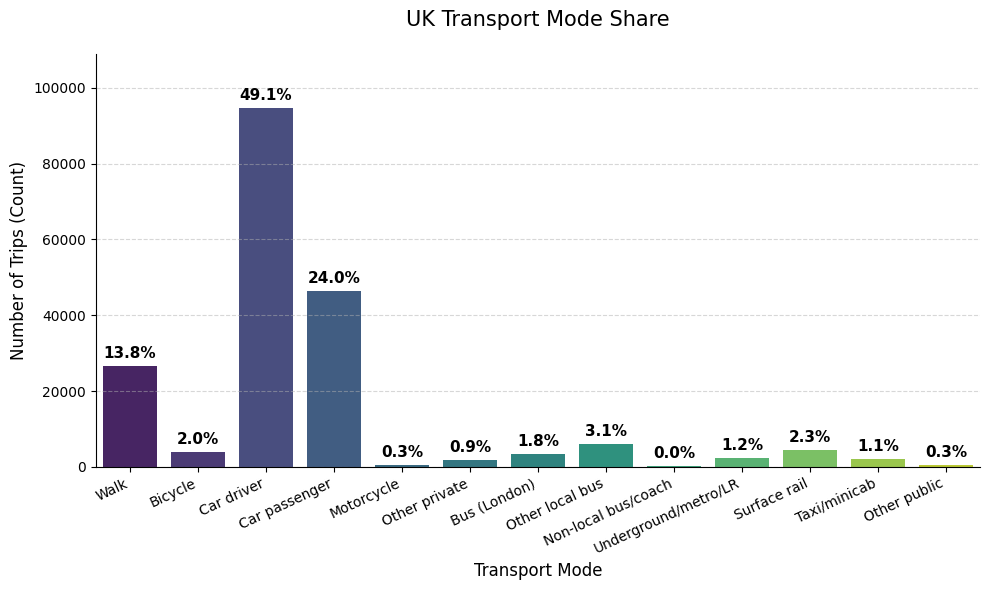

In [36]:
# Plot the mode share in the UK trips
plot_df = mode_table_all.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data = plot_df, 
    x = 'MainMode_B04ID', 
    y = 'count',
    hue = 'MainMode_B04ID',
    palette = 'viridis',
    legend=False
)

# Percentages on top of each bar
for i, p in enumerate(ax.patches):
    # Get the percentage from the 'pct' column
    percentage = plot_df['pct'].iloc[i]
    
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('UK Transport Mode Share', fontsize = 15, pad = 20)
plt.xlabel('Transport Mode', fontsize = 12)
plt.ylabel('Number of Trips (Count)', fontsize = 12)

# Increase Y-limit to make room for labels
plt.ylim(0, plot_df['count'].max() * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.xticks(rotation = 25, ha = "right")
plt.tight_layout()
plt.show()


In [37]:
# Then we are going to filter to car driver + PT + bicycle only
target_modes_mask = uk_data.MainMode_B04ID.isin(choice_modes_london)
uk_target_modes = uk_data[target_modes_mask].copy()

In [38]:
len(uk_target_modes) #Trips with car/PT/bike modes (UK-wide 2023)

110939

In [39]:
(len(uk_target_modes) / len(uk_data))*100 # Trips with car/PT/bike out of all trips in % in UK

57.52665311540696

In [40]:
# Count and percentage by purpose
purpose_counts = (uk_target_modes.TripPurpose_B04ID.value_counts().sort_index().rename(index=purpose_labels))
purpose_pct = (purpose_counts / purpose_counts.sum() * 100).round(2)
purpose_table = pd.DataFrame({"count": purpose_counts, "pct": purpose_pct})

In [41]:
purpose_table

,count,pct
TripPurpose_B04ID,,
Commuting,20099,18.12
Business,4256,3.84
Education,9653,8.70
Escort,22697,20.46
Shopping,12185,10.98
Other personal,11066,9.97
Leisure,30909,27.86
Other/walk,74,0.07


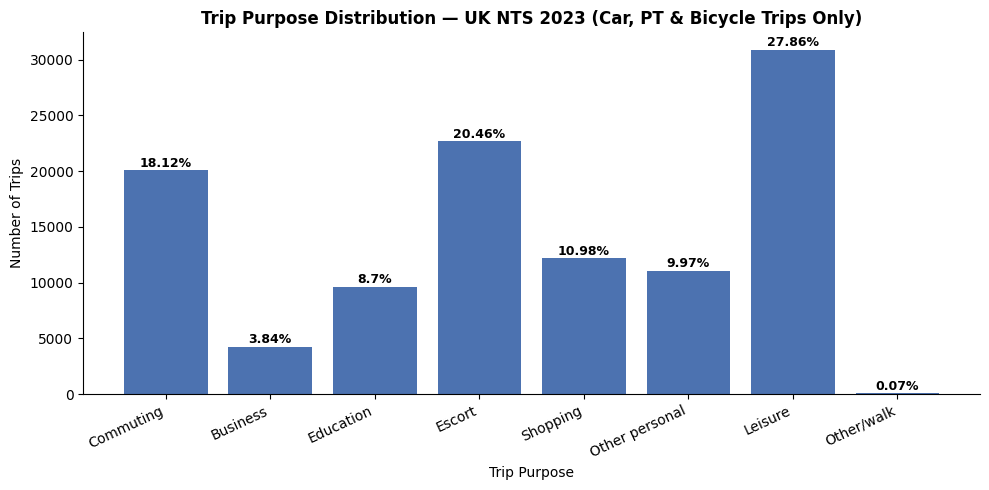

In [42]:
# Lets now visualize the mode share 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(purpose_table.index, purpose_table["count"], color="#4C72B0")

for bar, pct in zip(bars, purpose_table["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{pct}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Trip Purpose Distribution — UK NTS 2023 (Car, PT & Bicycle Trips Only)", fontsize = 12, fontweight = "bold")
ax.set_ylabel("Number of Trips")
ax.set_xlabel("Trip Purpose")
# ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation = 25, ha = "right")
plt.tight_layout()
plt.show()

From the above graph we can see that the most common purpose for a tirp in 2023 was "Leisure" while in the Amsterdam daa was "Shopping". What is interesting in the Londons' data is that we have the purpose "Escort" with the second highest trip purpose share with just above 20%. This purpose is missing in the Amsterdam data. From the official lookup table we see that "Escort" is fully described as "Education / escort education" which can be viewed as escorting the kids to school, sport classes or other activities. It can be interesting to see how these trips are corelated to the mode choice made for trips with purpose "Commuting". "Commuting" takes the third place for highest share of trip purposes with just 2.3% lower than "Escort".

As a next step, lets visualize what is the distribution of mode choice in the entire Londons dataset as we did with Amsterdam.

In [43]:
# Collapsed into our 3 choice-set categories
car_n  = uk_data.MainMode_B04ID.eq(mode_car_driver).sum()
pt_n = uk_data.MainMode_B04ID.isin(pt_codes_london).sum()
bike_n = uk_data.MainMode_B04ID.eq(mode_bicycle).sum()
other_n = len(uk_data) - car_n - pt_n - bike_n
total = len(uk_data)

In [44]:
print("Collapsed to choice set (car / PT / bike / other):")
for label, n in [("Car driver", car_n), ("PT (bus+underground)", pt_n),
                  ("Bicycle", bike_n), ("Other modes", other_n)]:
    print(f"  {label:25s}: {n:>7,}  ({100*n/total:.1f}%)")

Collapsed to choice set (car / PT / bike / other):
  Car driver               :  94,788  (49.2%)
  PT (bus+underground)     :  12,295  (6.4%)
  Bicycle                  :   3,856  (2.0%)
  Other modes              :  81,909  (42.5%)


In [45]:
# Reuse the apply_filter function from Amsterdam pipeline
transformation_log_london = []

def apply_filter(dataset, mask, description, log = transformation_log_london):
    n_before = len(dataset)
    dataset_r = dataset[mask].copy()
    n_after = len(dataset_r)
    n_dropped = n_before - n_after
    entry = f"{description}: {n_before:,} → {n_after:,} rows (dropped {n_dropped:,})"
    log.append(entry)
    print(entry)
    return dataset_r

london_data = uk_data.copy()

# F1: London only
london_data = apply_filter(
    london_data,
    london_data["PSUStatsReg_B01ID"] == london_code,
    f"F1: London residents (PSUStatsReg_B01ID == {london_code})"
)

F1: London residents (PSUStatsReg_B01ID == 8): 192,848 → 25,188 rows (dropped 167,660)


In [46]:
london_data.shape

(25188, 28)

In [47]:
london_data[(london_data.PSUStatsReg_B01ID == 8) & (london_data.TravelWeekDay_B02ID == 1) & (london_data.TripPurpose_B04ID == 1)].MainMode_B04ID.value_counts().sort_index() #mode share in London

MainMode_B04ID
1      299
2      288
3     1328
4      136
5       41
6       10
7      681
8       11
10    1070
11     760
12      19
13      26
Name: count, dtype: int64

### 5.3 Detailed Transport Mode Distribution — London Commuting

Before applying the 3-mode filter, we examine the full mode breakdown among London commuting trips. Then we can compare with the Amsterdam detailed mode distribution. First we are going to look at the mode choice for all transport means in the London area. Secondly, we are going to filter only for the modes we are interested in - car, pt and bike. 

In [48]:
# Temporarily filter to commuting only for this chart
london_commute_temp = london_data[london_data.TripPurpose_B04ID == commute_code_london].copy()

mode_dist_ldn = (
    london_commute_temp.MainMode_B04ID.value_counts().sort_index().rename(index = mode_labels_b04)
)

mode_pct_ldn = (mode_dist_ldn / mode_dist_ldn.sum() * 100).round(2)
mode_table_ldn = pd.DataFrame({"count": mode_dist_ldn, "pct": mode_pct_ldn})

In [49]:
mode_table_ldn

,count,pct
MainMode_B04ID,,
Walk,341,6.69
Bicycle,309,6.07
Car driver,1458,28.62
Car passenger,170,3.34
Motorcycle,47,0.92
Other private,12,0.24
Bus (London),756,14.84
Other local bus,17,0.33
Underground/metro/LR,1140,22.38


In [50]:
mode_table_ldn["count"].sum()

np.int64(5094)

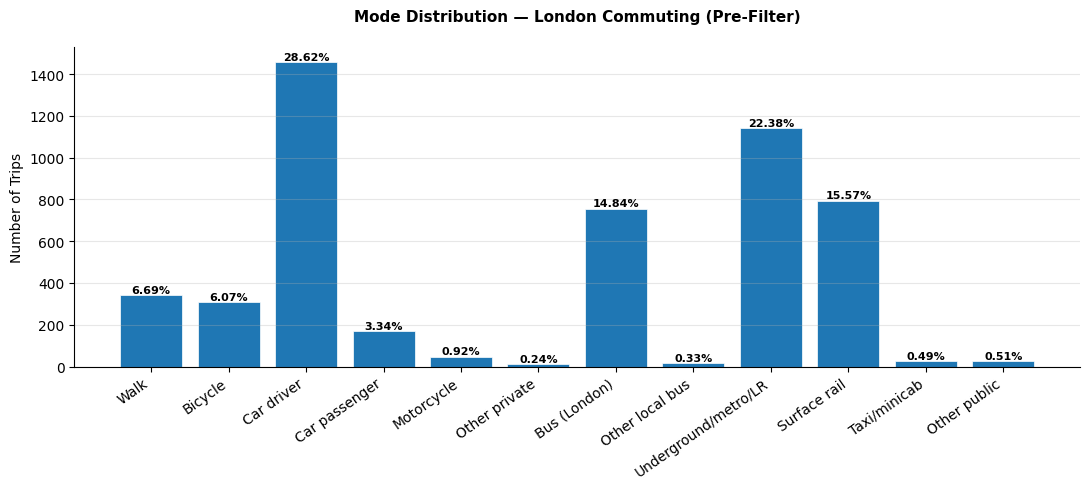

In [51]:
#lets plot the mode distribution
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(mode_table_ldn.index, mode_table_ldn["count"], edgecolor="white", linewidth=0.5)

for bar, pct in zip(bars, mode_table_ldn["pct"]):
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{pct}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_title("Mode Distribution — London Commuting (Pre-Filter)\n",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Trips")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [52]:
# F2: Commuting trips only
london_data = apply_filter(
    london_data,
    london_data.TripPurpose_B04ID == commute_code_london,
    "F2: Commuting trips only (TripPurpose_B04ID == 1)"
)

F2: Commuting trips only (TripPurpose_B04ID == 1): 25,188 → 5,094 rows (dropped 20,094)


In [53]:
# F3: Weekdays only (Mon–Fri)
london_data = apply_filter(
    london_data,
    london_data.TravelWeekDay_B01ID.isin(weekday_codes_london),
    "F3: Weekdays only (Mon–Fri)"
)

F3: Weekdays only (Mon–Fri): 5,094 → 4,669 rows (dropped 425)


In [54]:
# F4: Exclude public holidays / bank holidays
# A mask for a "pure" working day -> weekday which is not a bank holiday

london_data = apply_filter(
    london_data,
    london_data.TravelWeekDay_B02ID == normal_day_code,
    # normal_day_mask,
    f"F4: Normal days only (TravelDayType_B01ID == {normal_day_code})"
)

F4: Normal days only (TravelDayType_B01ID == 1): 4,669 → 4,669 rows (dropped 0)


In [55]:
# F5: Three modes only — car driver, PT (bus + underground), bicycle
london_data = apply_filter(
    london_data,
    london_data["MainMode_B04ID"].isin(choice_modes_london),
    "F5: Choice set modes only (car driver, PT, bicycle)"
)

F5: Choice set modes only (car driver, PT, bicycle): 4,669 → 3,404 rows (dropped 1,265)


In [56]:
# F6: Exclude short walk trips coded as trips
london_data = apply_filter(
    london_data,
    london_data["ShortWalkTrip_B01ID"] != 1,
    "F6: Exclude short walk trips (ShortWalkTrip_B01ID != 1)"
)

F6: Exclude short walk trips (ShortWalkTrip_B01ID != 1): 3,404 → 3,404 rows (dropped 0)


In [57]:
# F7: Exclude missing income
london_data = apply_filter(
    london_data,
    ~london_data[income_var_2023].isin(missing_codes),
    f"F7: Exclude missing income ({income_var_2023} not in {missing_codes})"
)

F7: Exclude missing income (HHIncQIS2023Eng_B01ID not in [-8, -9, -10]): 3,404 → 3,404 rows (dropped 0)


In [58]:
# F8: Exclude missing driving licence
london_data = apply_filter(
    london_data,
    ~london_data["DrivLic_B02ID"].isin(missing_codes),
    "F8: Exclude missing driving licence (DrivLic_B02ID)"
)

F8: Exclude missing driving licence (DrivLic_B02ID): 3,404 → 3,394 rows (dropped 10)


In [59]:
# F9: Exclude missing car ownership
london_data = apply_filter(
    london_data,
    ~london_data["NumCarVan"].isin(missing_codes),
    "F9: Exclude missing car ownership (NumCarVan)"
)

F9: Exclude missing car ownership (NumCarVan): 3,394 → 3,394 rows (dropped 0)


In [60]:
london_data.columns

Index(['TripID', 'DayID', 'IndividualID', 'HouseholdID', 'PSUID',
       'MainMode_B04ID', 'MainMode_B11ID', 'TripPurpose_B04ID', 'TripTravTime',
       'TripDisIncSW', 'TripStartHours', 'TripStartMinutes', 'NumStages',
       'n_transfers', 'has_transfer', 'ShortWalkTrip_B01ID', 'W5',
       'TravelWeekDay_B01ID', 'TravelWeekDay_B02ID', 'TravelDayType_B01ID',
       'Age_B04ID', 'Sex_B01ID', 'DrivLic_B02ID', 'NumCarVan',
       'HHIncQIS2023Eng_B01ID', 'HHoldGOR_B02ID', 'W3', 'PSUStatsReg_B01ID'],
      dtype='object')

In the below steps we are going to rename the columns we need to match the Amsterdam dataset columns.

In [62]:
london_clean = london_data.copy()

conditions = [
    london_clean["MainMode_B04ID"] == mode_car_driver,
    london_clean["MainMode_B04ID"].isin(pt_codes_london),
    london_clean["MainMode_B04ID"] == mode_bicycle,
]
labels = ["car", "pt", "bike"]
london_clean["chosen_mode"] = np.select(conditions, labels, default = None)

In [63]:
london_clean.chosen_mode.value_counts()

chosen_mode
pt      1783
car     1328
bike     283
Name: count, dtype: int64

In [64]:
miles_to_km = 1.609344
london_clean["distance_km"] = london_clean.TripDisIncSW * miles_to_km # Convert distance: miles to km = 1.609344

We see that we have 29 empty values which are saved as a free space (' ') for the TripStartHours indicating when a trip started. Before we apply the filter for the peak hours we need to handle those values. 

In [65]:
london_clean["TripStartHours"] = pd.to_numeric(london_clean.TripStartHours, errors='coerce') #We convert the data to numeric so we make the 29 records as NaN
london_clean["TripStartHours"] = london_clean.TripStartHours.fillna(-1).astype(int) # Fill the 29 NaNs with a non-peak placeholder = -1, so we do not lose the records - we flag them. 

In [66]:
london_clean.TripStartHours.value_counts().sort_index()

TripStartHours
-1      29
 0       8
 1      11
 2       3
 3      26
 4      27
 5      87
 6     234
 7     405
 8     531
 9     164
 10     71
 11     47
 12     40
 13     78
 14    129
 15    137
 16    231
 17    417
 18    393
 19    132
 20     78
 21     44
 22     45
 23     27
Name: count, dtype: int64

In [67]:
# Insert peak-hour flag
london_clean["is_peak"] = (
    london_clean.TripStartHours.between(am_peak_start, am_peak_end) | 
    london_clean.TripStartHours.between(pm_peak_start, pm_peak_end)
).astype(int)

In [68]:
london_clean[london_clean.is_peak == 1].TripStartHours.value_counts().sort_index() # 2042 trips in peak_hours

TripStartHours
6     234
7     405
8     531
9     164
16    231
17    417
18    393
19    132
Name: count, dtype: int64

In [69]:
# Has driving licence 1 = full
london_clean["has_driving_license"] = (london_clean.DrivLic_B02ID == full_licence_code).astype(int)

In [70]:
# Add city column
london_clean["city"] = "London"

In [71]:
# --- 6f. Rename to shared schema ---
rename_map = {
    "IndividualID": "person_id",
    "TripID": "trip_id",
    "TripPurpose_B04ID": "trip_purpose",
    "MainMode_B04ID": "mode_detailed",
    "TripTravTime": "travel_time_min",
    "TripStartHours": "departure_hour",
    "NumStages" : "n_legs",
    "TravelWeekDay_B01ID": "weekday",
    "TravelDayType_B01ID": "is_holiday",
    "Age_B04ID": "age_band",
    "Sex_B01ID": "gender",
    income_var_2023: "income_quintile",
    "NumCarVan": "n_cars_household",
    "W5": "weight_trip",
    "W3": "weight_person"
}
london_clean = london_clean.rename(columns = rename_map)

In [72]:
# --- 6g. Select only shared schema columns ---
london_clean = london_clean[shared_columns].copy()

In [73]:
#We convert the n_cars_households and weight_trip from object to respectively float and int 

london_clean['n_cars_household'] = pd.to_numeric(london_clean.n_cars_household, errors = 'coerce').astype('int64')
london_clean['weight_trip'] = pd.to_numeric(london_clean.weight_trip, errors = 'coerce')

In [74]:
london_clean.dtypes

person_id                int64
trip_id                  int64
trip_purpose             int64
mode_detailed            int64
travel_time_min        float64
distance_km            float64
departure_hour           int64
weekday                  int64
is_holiday               int64
age_band                 int64
gender                   int64
income_quintile          int64
has_driving_license      int64
n_cars_household         int64
weight_trip            float64
weight_person          float64
city                    object
is_peak                  int64
chosen_mode             object
n_transfers               int8
has_transfer              int8
n_legs                   int64
dtype: object

In [75]:
london_clean.chosen_mode.value_counts()

chosen_mode
pt      1783
car     1328
bike     283
Name: count, dtype: int64

We are going to clean the outliers using shared thresholds from the Amsterdam cleaning data process. Same thresholds as Amsterdam for cross-city comparability are applied here as well.

In [76]:
# Travel time: 2–120 min
london_clean = apply_filter(
    london_clean,
    london_clean.travel_time_min.between(min_trip_dur, max_trip_dur),
    f"F10: Travel time within {min_trip_dur}–{max_trip_dur} min"
)

F10: Travel time within 2–120 min: 3,394 → 3,388 rows (dropped 6)


In [77]:
# Distance: 0.2–50 km
london_clean = apply_filter(
    london_clean,
    london_clean.distance_km.between(min_trip_distance, max_trip_distance),
    f"F11: Distance {min_trip_distance}–{max_trip_distance} km"
)

F11: Distance 0.2–50 km: 3,388 → 3,315 rows (dropped 73)


### 5.4 Travel Time and Distance Distributions by Mode — London

In the below cells we are going to find the mode choice distribution per travel time and trip duration as we did in the Amsterdam data pipelin.   

These distributions reveal the choice frequency profile per mode: how travel time and distance shape the usage of car, public transport, and bicycle in London commuting. Directly comparable to the Amsterdam equivalents.

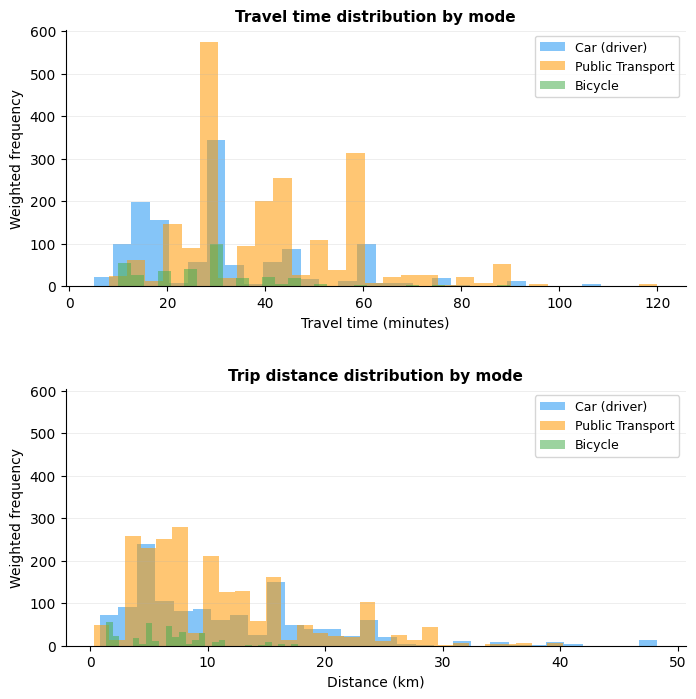

In [78]:
variables  = ["travel_time_min", "distance_km"]
mode_colors = {"car": "#2196F3", "pt": "#FF9800", "bike": "#4CAF50"}
transport_modes = ["car", "pt", "bike"]
mode_labels = {"car": "Car (driver)", "pt": "Public Transport", "bike": "Bicycle"}

fig, axes = plt.subplots(2,1, figsize = (8, 8),sharex = False ,sharey = True)

for ax, var in zip(axes, variables):
    for mode in transport_modes:
        subset = london_clean[london_clean.chosen_mode == mode]
        # Weighted histogram using survey weights
        ax.hist(
            subset[var],
            weights = subset.weight_trip,
            bins = 30,
            alpha = 0.55,
            color = mode_colors[mode],
            label = mode_labels[mode],
            edgecolor = "none"
        )
    ax.set_xlabel("Travel time (minutes)" if var == "travel_time_min" else "Distance (km)", fontsize = 10)
    ax.set_ylabel("Weighted frequency", fontsize = 10)
    ax.set_title("Travel time distribution by mode" if var == "travel_time_min" else "Trip distance distribution by mode",
                 fontsize = 11, fontweight = "bold")
    ax.legend(fontsize = 9)
    ax.grid(axis = "y", alpha = 0.3, linewidth = 0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.subplots_adjust(hspace = 0.4)
# plt.tight_layout()
# plt.savefig("data/raw/odin/path", dpi=150, bbox_inches="tight")
plt.show()

Describe the above two graphs and distributions 

The above distributions shows the modal preferences based on travel time and trip distnace in London. 

Looking at the Travel Time graph public transport is the primary choice for mid-duration trips, specifically those taking about 30 minutes. Weighted frequency peaks at three time durations. Respectively at 30, 45 and 60 minutes with the highest peak observed at 30th minute. Interestingly, the peak at the 60th minute is higher than the one observed for trips taking  45 minutes. This can be due to Londons public transport network specifics or commuters preferences for longer trips. 

For London commuters the car choice is also most concentrated around the 30-minute mark. Yet, the car seems to be the preffered mode choice for short trip commuters spending up to 20 minutes traveling while the PT choice increase for mid and long-duration trips.      

On the trip distance distribution graph PT seems to dominate the short-distance travel under 10 km. Even over the 10 km threshold, PT choice remains higher than the other two transport modes but PT frequencies decrease smoothly and gradually.
Car choice maintains a steady frequency for distances up to 20 km with highest peaks observed at 5th and 15th kilometer marks.

Bikes choice for commuting is not so strong as in Amsterdam where this mode is the dominant for short distance trips. In London bike frequency is considerably lower than the PT and car values but there are still commuters who prefer to spend 30min riding than taking the PT.    

It is interesting to see what is the spread of the values of our three variables and if there are outliers as we did with Amsterdam. We are going to measure again the spread of the middle 50% of our london_clean set. To do that we need to find the quantiles Q1(25th percentile) and Q3(75th percentile) of our chosen_mode variable. We are going to calculate the Interquartile Range (IQR) which is where 50% of our data is distributed by applying the formula IQR = Q3 - Q1. 

To decide what is too far from the middle we need to set the "fences" (boundaries): 
1. Lower Fence = $Q1 - (1.5 * IQR)$
2. Upper Fence = $Q3 + (1.5 * IQR)$

Why 1.5? This a heuristic established by John Tukey. In a perfectly normal distribution, 1.5 IQRs covers about 99.3% of the data, making anything outside that range statistically rare.

In [79]:
# 1. Melt the data so variables are in a single column for grouping
lnd_melted = london_clean.melt(id_vars = ['chosen_mode'], value_vars = variables)

In [80]:
lnd_melted.head(5)

,chosen_mode,variable,value
0,pt,travel_time_min,60.0
1,pt,travel_time_min,40.0
2,pt,travel_time_min,15.0
3,pt,travel_time_min,47.0
4,pt,travel_time_min,60.0


In [81]:
# 2. Calculate Q1 and Q3 per group
lnd_stats = lnd_melted.groupby(['variable', 'chosen_mode'],observed = False).value.quantile([0.25, 0.75]).unstack()
lnd_stats.columns = ['Q1', 'Q3']

In [82]:
lnd_stats.head(5)

Q1         Q3
variable        chosen_mode                      
distance_km     bike          4.828032   8.851392
                car           4.828032  16.093440
                pt            6.115507  16.093440
travel_time_min bike         20.000000  33.500000
                car          20.000000  38.000000

In [83]:
# 3. Define the upper and lower boundaries (fences)
lnd_stats['iqr'] = lnd_stats.Q3 - lnd_stats.Q1 
lnd_stats['lower'] = lnd_stats.Q3 - 1.5 * lnd_stats.iqr
lnd_stats['upper'] = lnd_stats.Q3 + 1.5 * lnd_stats.iqr

In [84]:
# 4. Count outliers by merging stats back to the melted data
lnd_merged = lnd_melted.merge(lnd_stats, on = ['variable', 'chosen_mode'])
lnd_merged['is_outlier'] = (lnd_merged.value < lnd_merged.lower) | (lnd_merged.value > lnd_merged.upper)
n_outliers = lnd_merged.groupby(['variable', 'chosen_mode'], observed = False).is_outlier.sum().reset_index()

In [85]:
lnd_merged.head(10)

,chosen_mode,variable,value,Q1,Q3,iqr,lower,upper,is_outlier
0,pt,travel_time_min,60.0,30.0,55.0,25.0,17.50,92.50,False
1,pt,travel_time_min,40.0,30.0,55.0,25.0,17.50,92.50,False
2,pt,travel_time_min,15.0,30.0,55.0,25.0,17.50,92.50,True
3,pt,travel_time_min,47.0,30.0,55.0,25.0,17.50,92.50,False
4,pt,travel_time_min,60.0,30.0,55.0,25.0,17.50,92.50,False
5,bike,travel_time_min,30.0,20.0,33.5,13.5,13.25,53.75,False
6,pt,travel_time_min,35.0,30.0,55.0,25.0,17.50,92.50,False
7,car,travel_time_min,31.0,20.0,38.0,18.0,11.00,65.00,False
8,pt,travel_time_min,45.0,30.0,55.0,25.0,17.50,92.50,False
9,pt,travel_time_min,20.0,30.0,55.0,25.0,17.50,92.50,False


In [86]:
n_outliers

,variable,chosen_mode,is_outlier
0,distance_km,bike,78
1,distance_km,car,37
2,distance_km,pt,27
3,travel_time_min,bike,53
4,travel_time_min,car,180
5,travel_time_min,pt,99


In [87]:
# 5. Build final report
lnd_report = lnd_stats.reset_index().merge(n_outliers, on = ['variable', 'chosen_mode'])
lnd_report['mode'] = lnd_report.chosen_mode.map(mode_labels)

In [88]:
lnd_report

,variable,chosen_mode,Q1,Q3,iqr,lower,upper,is_outlier,mode
0,distance_km,bike,4.828032,8.851392,4.023360,2.816352,14.886432,78,Bicycle
1,distance_km,car,4.828032,16.093440,11.265408,-0.804672,32.991552,37,Car (driver)
2,distance_km,pt,6.115507,16.093440,9.977933,1.126541,31.060339,27,Public Transport
3,travel_time_min,bike,20.000000,33.500000,13.500000,13.250000,53.750000,53,Bicycle
4,travel_time_min,car,20.000000,38.000000,18.000000,11.000000,65.000000,180,Car (driver)
5,travel_time_min,pt,30.000000,55.000000,25.000000,17.500000,92.500000,99,Public Transport


Looking at the bicycle data, we can say taht people use bikes for very specific and consistent trips. Most of the bike trips are kept within a tight window of about five to nine kilometers, showing that cycling is the choice for short-range commutes. Interestingly, the travel time of bike commuting doesn't vary much but just over 13 mins, cyclists seem to have a much better handle on their arrival times compared to other commutersn. 

The car data tells a much more varied story because it covers everything from quick trips to long-distance commutes. Unlike the other modes, the distance people are choosing to drive, which explains why the statistical spread is so wide. 

One of the biggest takeaways here is the massive number of time outliers. With 180 instances of extreme travel times, it is clear that drivers are frequently dealing with heavy traffic or exceptionally long commutes that push well past an hour. This makes the car a versatile tool but also a much more unpredictable one when things like rush hour come into play.

Public transport has a very distinct characteristics in this dataset, mainly because it takes longer to get moving. The lower time boundary is higher than the one for cars starting at the thirty-minute mark. While it covers roughly the same distances as driving, the time it takes to do so is much less certain. With the widest range of "typical" travel times, PT users face a lot of variability in their daily schedules.

In [ ]:
# Load remaining tables and filter to 2023 PSUIDs
def load_and_filter(filepath, psu_ids, label):
    """Load tab file, keep rows matching 2023 PSUIDs."""
    dataset = pd.read_csv(filepath, sep="\t", low_memory = False)
    n_total = len(dataset)
    dataset = dataset[dataset.PSUID.isin(psu_ids)].copy()

    print(f"{label}: {n_total:,} total → {len(dataset):,} rows for {survey_year}")

    return dataset

household_2023 = load_and_filter(nts_files["household"], psu_ids_2023, "Household")
individual_2023 = load_and_filter(nts_files["individual"], psu_ids_2023, "Individual")
day_2023 = load_and_filter(nts_files["day"], psu_ids_2023, "Day")
trip_2023 = load_and_filter(nts_files["trip"], psu_ids_2023, "Trip")

In [ ]:
# Reuse the apply_filter function from Amsterdam pipeline
transformation_log_london = []

def apply_filter(dataset, mask, description, log = transformation_log_london):
    n_before = len(dataset)
    dataset_r = dataset[mask].copy()
    n_after = len(dataset_r)
    n_dropped = n_before - n_after
    entry = f"{description}: {n_before:,} → {n_after:,} rows (dropped {n_dropped:,})"
    log.append(entry)
    print(entry)
    return dataset_r

london_data = uk_data.copy()

# F1: London only
london_data = apply_filter(
    london_data,
    london_data["PSUStatsReg_B01ID"] == london_code,
    f"F1: London residents (PSUStatsReg_B01ID == {london_code})"
)

# F2: Commuting trips only
london_data = apply_filter(
    london_data,
    london_data["TripPurpose_B04ID"] == commute_code_london,
    "F2: Commuting trips only (TripPurpose_B04ID == 1)"
)

# F3: Weekdays only (Mon–Fri)
london_data = apply_filter(
    london_data,
    london_data["TravelWeekDay_B01ID"].isin(weekday_codes_london),
    "F3: Weekdays only (Mon–Fri)"
)

# F4: Exclude public holidays / bank holidays
# A mask for a "pure" working day -> weekday which is not a bank holiday

london_data = apply_filter(
    london_data,
    london_data.TravelWeekDay_B02ID == normal_day_code,
    # normal_day_mask,
    f"F4: Normal days only (TravelDayType_B01ID == {normal_day_code})"
)

# F5: Three modes only — car driver, PT (bus + underground), bicycle
london_data = apply_filter(
    london_data,
    london_data["MainMode_B04ID"].isin(choice_modes_london),
    "F5: Choice set modes only (car driver, PT, bicycle)"
)

# F6: Exclude short walk trips coded as trips
london_data = apply_filter(
    london_data,
    london_data["ShortWalkTrip_B01ID"] != 1,
    "F6: Exclude short walk trips (ShortWalkTrip_B01ID != 1)"
)

# F7: Exclude missing income
london_data = apply_filter(
    london_data,
    ~london_data[income_var_2023].isin(missing_codes),
    f"F7: Exclude missing income ({income_var_2023} not in {missing_codes})"
)

# F8: Exclude missing driving licence
london_data = apply_filter(
    london_data,
    ~london_data["DrivLic_B02ID"].isin(missing_codes),
    "F8: Exclude missing driving licence (DrivLic_B02ID)"
)

# F9: Exclude missing car ownership
london_data = apply_filter(
    london_data,
    ~london_data["NumCarVan"].isin(missing_codes),
    "F9: Exclude missing car ownership (NumCarVan)"
)

#F10 Travel time between: 2 and 120 min
london_clean = apply_filter(
    london_clean,
    london_clean.travel_time_min.between(min_trip_dur, max_trip_dur),
    f"F10: Travel time within {min_trip_dur}–{max_trip_dur} min"
)

#F11 Distance: 0.2–50 km
london_clean = apply_filter(
    london_clean,
    london_clean.distance_km.between(min_trip_distance, max_trip_distance),
    f"F11: Distance {min_trip_distance}–{max_trip_distance} km"
)

In [89]:
# --- Export ---
london_clean.to_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\processed\lnd_processed.csv", index=False)
print(f"\n Processed dataset saved to data\processed")


 Processed dataset saved to data\processed
